In [7]:
from pathlib import Path


from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob


client = AereoClient()
job = ExtractionJob.load_from_config(
    config_dir=(Path(".").parent / "config").resolve(),
    config_name="job.yaml",
)

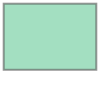

In [8]:
job.target_aoi

In [9]:
# Search
search_results = client.search(job.search)
print(f"✓ Found {len(search_results)} scenes")

2026-06-15 19:38:01 [info     ] search_called                  provider=SearchSTAC
✓ Found 16 scenes


In [ ]:
# Prepare
print("\n📦 Preparing tasks...")
tasks = client.prepare_tasks(
    search_results=search_results,
    job=job,
    cells_per_task=5,
)
print(f"✓ Prepared {len(tasks)} tasks")


📦 Preparing tasks...
✓ Prepared 8 tasks


In [15]:
# Extract
print("\n⛏️ Extracting...")
backend = LocalProcessBackend(max_workers=8)
artifacts = client.execute_tasks(tasks, backend=backend)
print(f"✓ Extracted {len(artifacts)} artifacts")


⛏️ Extracting...
2026-06-15 19:38:41 [info     ] execute_tasks_start            backend=LocalProcessBackend failure_mode=strict task_count=8
✓ Extracted 38 artifacts


In [16]:
artifacts.iloc[120].uri

IndexError: single positional indexer is out-of-bounds

In [ ]:
import rioxarray

rioxarray.open_rasterio(artifacts.iloc[120].uri)[0].plot()